In [75]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import numpy as np
import keras

Definição de parametros do dataset para separação dos dados

In [62]:
DATA_DIR = "datatest"
BATCH_SIZE = 32
IMG_WIDTH = 224
IMG_HEIGHT = 224

Dados para treino

In [63]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
)


Found 4248 files belonging to 2 classes.
Using 3399 files for training.


Dados de validação

In [64]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
)

Found 4248 files belonging to 2 classes.
Using 849 files for validation.


Identificação das Classes de identificação das imagens

In [65]:
class_names = train_ds.class_names
print(class_names)

['incendio', 'naoIncendio']


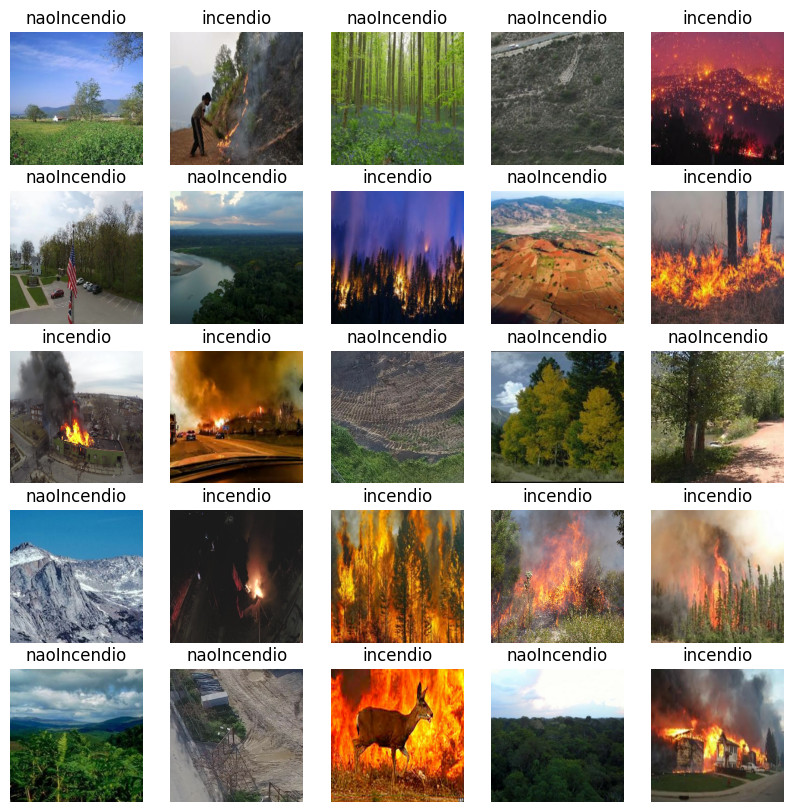

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [67]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 224, 224, 3)
(32,)


In [68]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Padronização dos dados

In [69]:
normalization_layer = layers.Rescaling(1./255)

Criação do Modelo

In [70]:
numClasses = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(numClasses)
])      

In [71]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,498 (24.59 MB)

 Trainable params: 6,446,498 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

Treinamento do Modelo

In [72]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 22s 184ms/step - accuracy: 0.8767 - loss: 0.3277 - val_accuracy: 0.9164 - val_loss: 0.1847
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.9212 - loss: 0.2042 - val_accuracy: 0.9176 - val_loss: 0.2120
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 0.9376 - loss: 0.1661 - val_accuracy: 0.9458 - val_loss: 0.1227
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 0.9544 - loss: 0.1193 - val_accuracy: 0.9517 - val_loss: 0.1173
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.9688 - loss: 0.0823 - val_accuracy: 0.9564 - val_loss: 0.1510
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.9759 - loss: 0.0669 - val_accuracy: 0.9340 - val_loss: 0.1929
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.9741 - loss: 0.0695 - val_accuracy: 0.9411 - val_loss: 0.1709
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.9865 - loss: 0

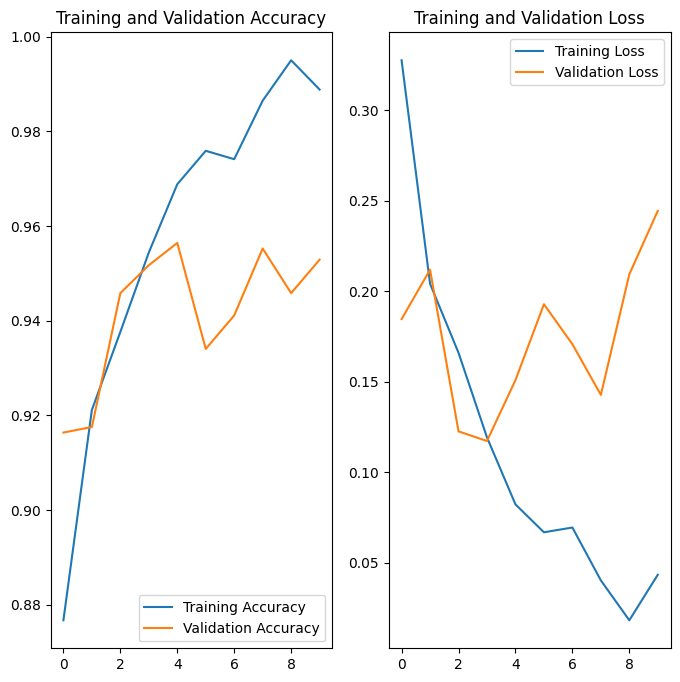

In [73]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']  
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Aumento de dados

In [77]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(IMG_HEIGHT,
                                  IMG_WIDTH,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

c:\reconhecimentoImagem\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


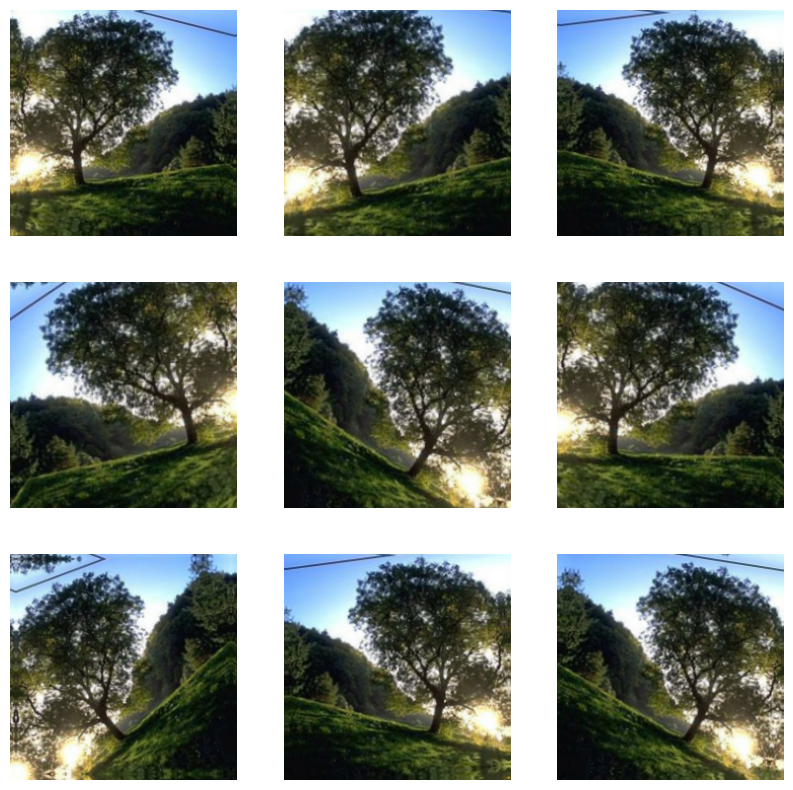

In [78]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

Treinando novamente o modelo

In [79]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 182ms/step - accuracy: 0.9938 - loss: 0.0190 - val_accuracy: 0.9552 - val_loss: 0.1608
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - accuracy: 0.9985 - loss: 0.0082 - val_accuracy: 0.9140 - val_loss: 0.3790
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 0.9926 - loss: 0.0202 - val_accuracy: 0.9623 - val_loss: 0.2161
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9611 - val_loss: 0.2081
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 1.0000 - loss: 4.3596e-04 - val_accuracy: 0.9576 - val_loss: 0.2163
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 181ms/step - accuracy: 1.0000 - loss: 2.0604e-04 - val_accuracy: 0.9600 - val_loss: 0.2266
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 1.0000 - loss: 1.4939e-04 - val_accuracy: 0.9600 - val_loss: 0.2315
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 1.00

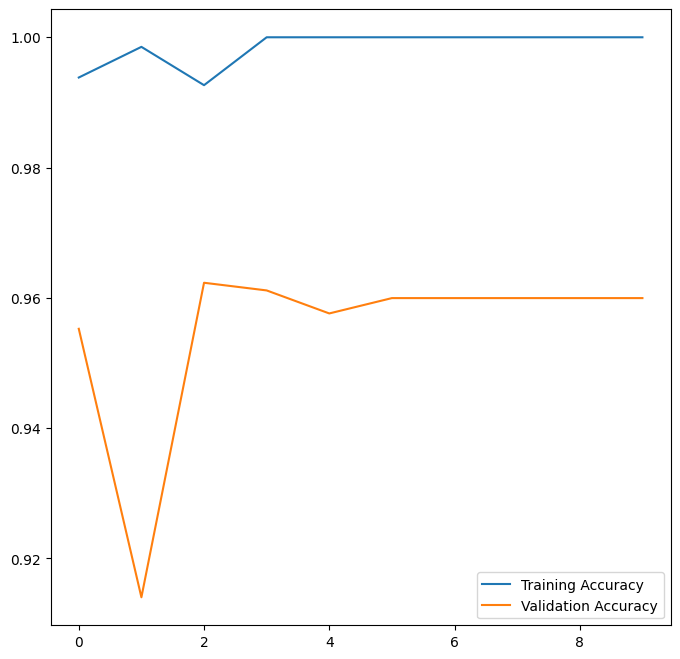

In [82]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.figure(figsize=(8, 8))
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

Função de Reconhecer novas imagens

In [114]:
imgPath = "../reconhecimentoImagem/assets/minha_imagem.jpg"

def predict_image(model, imgPath, class_names):
    img = tf.keras.preprocessing.image.load_img(
        imgPath, target_size=(IMG_HEIGHT, IMG_WIDTH)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) 

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    return class_names[np.argmax(score)], 100 * np.max(score)

predict, accuracy = predict_image(model, imgPath, class_names)

print(f"Classe: {predict}, Precissão {accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Classe: incendio, Precissão 99.99979400634766


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


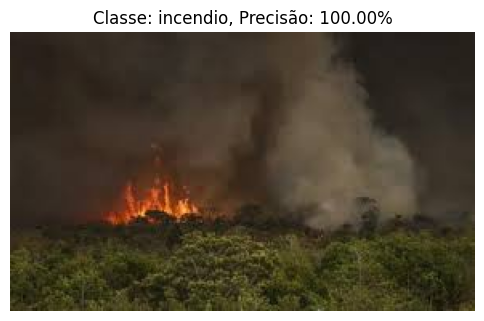

In [115]:
imgPath = "../reconhecimentoImagem/assets/minha_imagem.jpg"

predict, accuracy = predict_image(model, imgPath, class_names)

plt.figure(figsize=(6, 6))
plt.imshow(tf.keras.preprocessing.image.load_img(imgPath))
plt.title(f"Classe: {predict}, Precisão: {accuracy:.2f}%")
plt.axis("off")
plt.show()

In [101]:
model.save("reconhecimento_incendio.keras")